In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/rajes/Downloads/players_15.csv.zip")
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,FC Barcelona,...,62+3,62+3,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,Real Madrid,...,63+3,63+3,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,FC Bayern München,...,64+3,64+3,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,Paris Saint-Germain,...,61+3,65+3,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,FC Bayern München,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
cols_to_keep = ['short_name', 'age', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'preferred_foot']
df = df[cols_to_keep]

df['value_eur'] = df['value_eur'].fillna(df['value_eur'].median())
df['wage_eur'] = df['wage_eur'].fillna(df['wage_eur'].median())
df['club'] = df['club'].fillna('Free Agent')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15465 entries, 0 to 15464
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   short_name      15465 non-null  object
 1   age             15465 non-null  int64 
 2   nationality     15465 non-null  object
 3   club            15465 non-null  object
 4   overall         15465 non-null  int64 
 5   potential       15465 non-null  int64 
 6   value_eur       15465 non-null  int64 
 7   wage_eur        15465 non-null  int64 
 8   preferred_foot  15465 non-null  object
dtypes: int64(5), object(4)
memory usage: 1.1+ MB


In [8]:
nation_counts = df['nationality'].value_counts().head(10).reset_index()
nation_counts.columns = ['nationality', 'player_count']

age_stats = df.groupby('age')['overall'].mean().reset_index()

club_stats = df.groupby('club')['overall'].mean().sort_values(ascending=False).head(10).reset_index()
club_stats.columns = ['club', 'avg_overall']

foot_dist = df['preferred_foot'].value_counts().reset_index()
foot_dist.columns = ['preferred_foot', 'count']

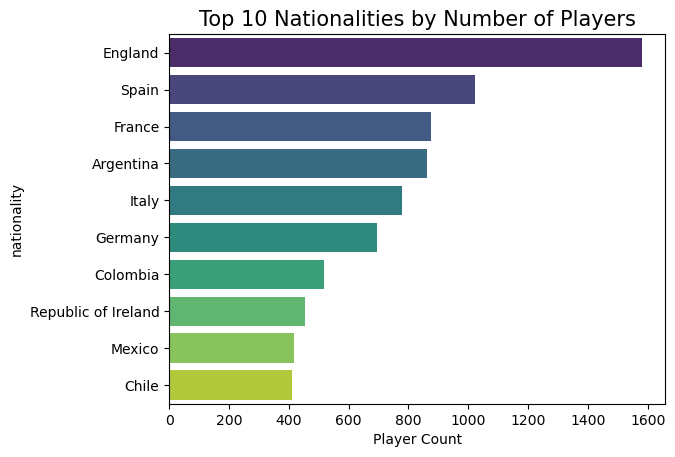

In [9]:
sns.barplot(data=nation_counts, x='player_count', y='nationality', hue='nationality', palette='viridis', legend=False)
plt.title("Top 10 Nationalities by Number of Players", fontsize=15)
plt.xlabel("Player Count")
plt.show()

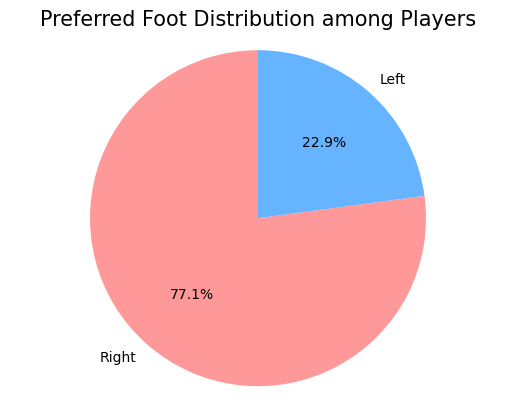

In [10]:
plt.pie(foot_dist['count'], labels=foot_dist['preferred_foot'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Preferred Foot Distribution among Players", fontsize=15)
plt.axis('equal')
plt.show()

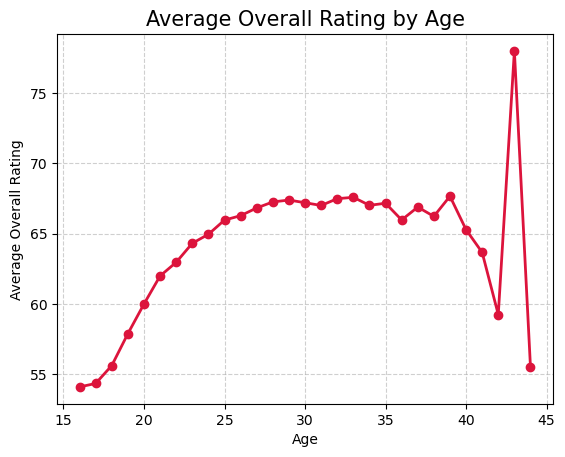

In [11]:
plt.plot(age_stats['age'], age_stats['overall'], marker='o', color='crimson', linewidth=2)
plt.title("Average Overall Rating by Age", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Average Overall Rating")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

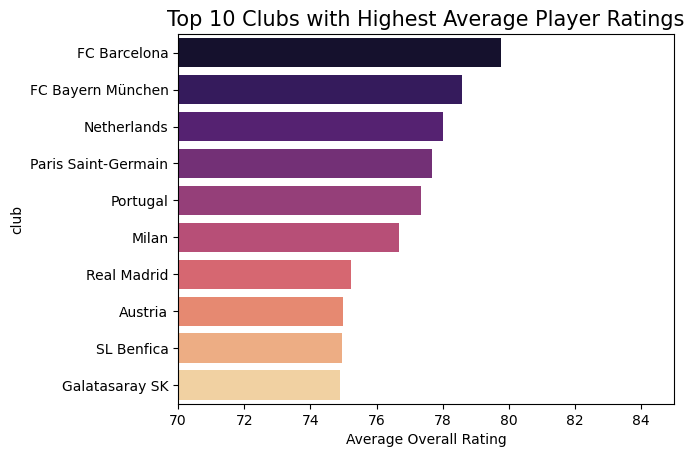

In [12]:
sns.barplot(data=club_stats, x='avg_overall', y='club', hue='club', palette='magma', legend=False)
plt.title("Top 10 Clubs with Highest Average Player Ratings", fontsize=15)
plt.xlabel("Average Overall Rating")
plt.xlim(70, 85)
plt.show()